In [1]:
# import DMeRates
import DMeRates.DMeRate as DMeRate
import torch
import numericalunits as nu
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
plt.rcParams['text.usetex'] = True  # Enable LaTeX
params = {'text.usetex' : True,
            'font.size' : 12,
            'font.family' : 'cmr10',
            'figure.autolayout': True
            }
plt.rcParams.update(params)
plt.rcParams['axes.unicode_minus']=False
plt.rcParams['axes.labelsize']=10

In [2]:
FDMn = 2
halo_model = 'shm'
DoScreen = False
test_mX = 10. #MeV
test_mX_eV = test_mX*1e6
test_mX_unitized= test_mX * nu.MeV / nu.c0**2
ne = 1
cs = 1e-36
cs_unitized = cs * nu.cm**2
nes = [1,2,3,4,5,6,7,8,9,10]
mX_array = np.concatenate((np.arange(0.2,0.8,0.025),np.array([0.9]),np.arange(1,5,0.05),np.arange(5,11,1),np.array([20,50,100,200,500,1000,10000]))) #MeV


In [3]:
import DMeRates
import DMeRates.DMeRate
dmrates_qedark = DMeRate.DMeRate('Si',QEDark=True)
dmrates = DMeRate.DMeRate('Si',QEDark=False)
dmrates.update_crosssection(cs)
dmrates_qedark.update_crosssection(cs)



dmrates_qedark.setup_halo_data(test_mX,FDMn,'shm')
dmrates.setup_halo_data(test_mX,FDMn,'shm')

# drde_qcdark_redo_res = dmrates.vectorized_dRdE(test_mX,FDMn,halo_model,DoScreen=DoScreen,integrate=True,unitize=True,debug=True) 
drde_qedark_redo = dmrates_qedark.vectorized_dRdE(test_mX,FDMn,'imb',DoScreen=DoScreen,integrate=False,unitize=True,debug=False).cpu().numpy()
drde_qcdark_redo = dmrates.vectorized_dRdE(test_mX,FDMn,'shm',DoScreen=DoScreen,integrate=True,unitize=True,debug=False).cpu().numpy()
dmrates.setup_halo_data(test_mX,FDMn,'modulated',isoangle=35,useVerne=True)

Earr = dmrates.Earr.cpu().numpy()
Earr /= nu.eV

Earr_qedark = dmrates_qedark.Earr.cpu().numpy()
Earr_qedark /= nu.eV


CUDA GPU found, performing calculations on GPU
CUDA GPU found, performing calculations on GPU
Using form factor calculated from file: c:\Users\Ansh\Projects\DarkMatterRates\DMeRates\../form_factors/QCDark/Si_final.hdf5


c:\Users\Ansh\anaconda3\envs\dmerates\Lib\site-packages\torch\__init__.py:1236: UserWarning: torch.set_default_tensor_type() is deprecated as of PyTorch 2.1, please use torch.set_default_dtype() and torch.set_default_device() as alternatives. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\tensor\python_tensor.cpp:436.)
  _C._set_default_tensor_type(t)
c:\Users\Ansh\anaconda3\envs\dmerates\Lib\site-packages\torchquad\integration\simpson.py:76: UserWarning: N per dimension cannot be even due to necessary subdivisions. N per dim will now be changed to the next lower integer, i.e. 1250 -> 1249.
  warnings.warn(
c:\Users\Ansh\anaconda3\envs\dmerates\Lib\site-packages\torch\functional.py:539: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\TensorShape.cpp:3638.)
  return _VF.meshgrid(tensors, **kwargs)  # ty

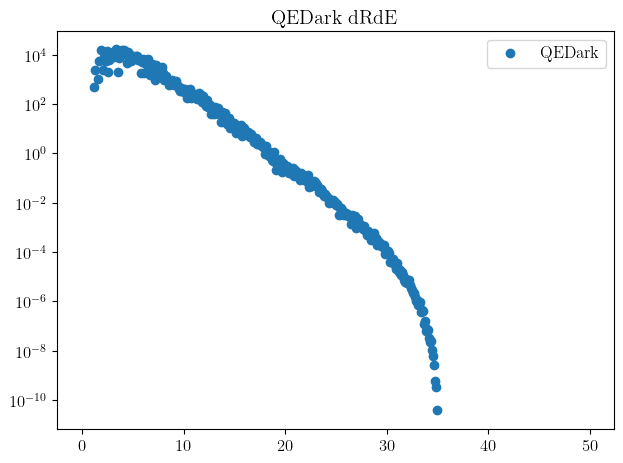

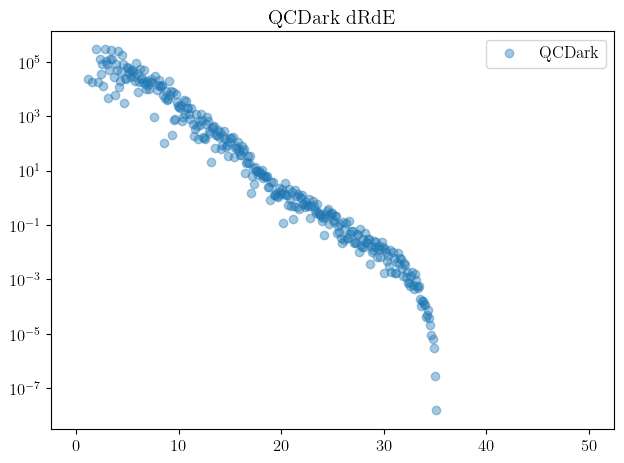

In [4]:


plt.scatter(Earr_qedark,drde_qedark_redo,label='QEDark')
plt.yscale('log')
plt.legend()
plt.title('QEDark dRdE')
plt.show()
plt.close()

plt.scatter(Earr,drde_qcdark_redo,label='QCDark',alpha=0.4)
plt.yscale('log')
plt.legend()
plt.title('QCDark dRdE')
plt.show()
plt.close()




In [5]:
import DMeRates
import DMeRates.DMeRate as DMeRate
dmrates = DMeRate.DMeRate('Si',QEDark=False)
dmrates_qedark = DMeRate.DMeRate('Si',QEDark=True)

CUDA GPU found, performing calculations on GPU
Using form factor calculated from file: c:\Users\Ansh\Projects\DarkMatterRates\DMeRates\../form_factors/QCDark/Si_final.hdf5
CUDA GPU found, performing calculations on GPU


In [6]:

import time
start = time.time()
qcdark_redo = dmrates.calculate_rates(mX_array,'shm',FDMn,ne=nes,integrate=True,DoScreen=DoScreen)[ne-1] *nu.kg*nu.year
end = time.time()
print(f"took {end - start}s")
qedark_redo = dmrates_qedark.calculate_rates(mX_array,'imb',FDMn,ne=nes,integrate=False,DoScreen=DoScreen)[ne-1] *nu.kg*nu.year
end2 = time.time()
print(f"took {end2 - end}s")


took 0.5604918003082275s
took 0.30220985412597656s


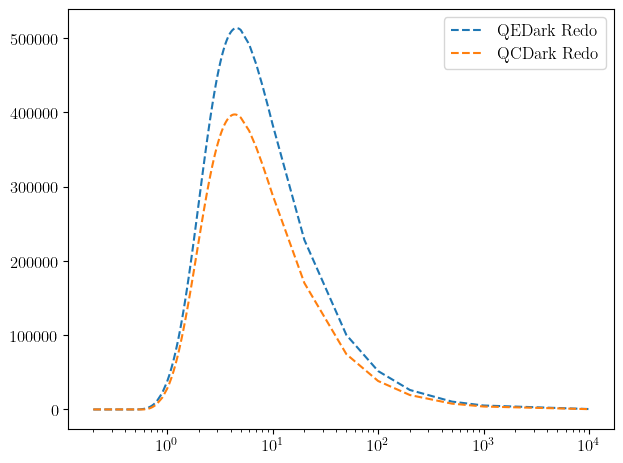

In [8]:
plt.plot(mX_array,qedark_redo.cpu().numpy(),label='QEDark Redo',ls='--')
plt.plot(mX_array,qcdark_redo.cpu().numpy(),label='QCDark Redo',ls='--')

plt.legend()
plt.xscale('log')
# plt.yscale('log')

plt.show()
plt.close()

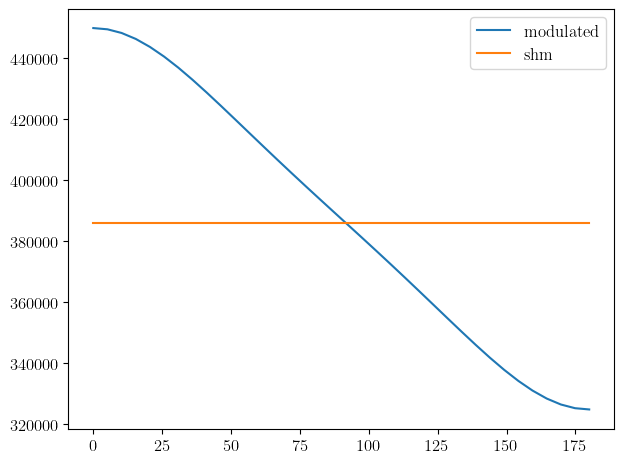

took 0.3870258331298828s


In [23]:
test_mX = 1.
test_cs = 1e-34
dmrates.update_crosssection(test_cs)
FDMn = 2
isoangles = np.linspace(0,180,36)
rate_per_angle = np.zeros(36)
rate_flat = np.zeros(36)
import time
start = time.time()
for isoangle in range(36):
    r = dmrates.calculate_rates(test_mX,'modulated',FDMn,ne=nes,integrate=True,DoScreen=True,isoangle=isoangle,useVerne=True)[ne-1] *nu.kg*nu.year
    rate_per_angle[isoangle] = r.cpu()
    r = dmrates.calculate_rates(test_mX,'shm',FDMn,ne=nes,integrate=True,DoScreen=True,isoangle=None)[ne-1] *nu.kg*nu.year
    rate_flat[isoangle] = r.cpu()
end = time.time()

plt.plot(isoangles,rate_per_angle,label='modulated')
plt.plot(isoangles,rate_flat,label='shm')
plt.legend()
plt.show()
plt.close()
print(f"took {end - start}s")

In [9]:
#this is for testing wimprates
import DMeRates
import DMeRates.DMeRate as DMeRate
material = 'Xe'
dmrates = DMeRate.DMeRate(material)
import numpy as np

import numericalunits as nu
from DMeRates.Constants import *


CUDA GPU found, performing calculations on GPU


In [17]:
test_shell = '5p'
test_mX = 1000
test_mX_unitized = test_mX * nu.MeV / nu.c0**2
test_mX_eV = 1000*1e6

test_cs = 1e-34
FDMn = 0
halo_model = 'shm'

dmrates.update_crosssection(test_cs)

dmrates.setup_halo_data(test_mX,FDMn,'shm')

drs = dmrates.noble_dRdE(test_mX,FDMn,halo_model,halo_id_params=None,debug=False,unitize=True)
erec = dmrates.Earr.cpu().numpy() / nu.eV

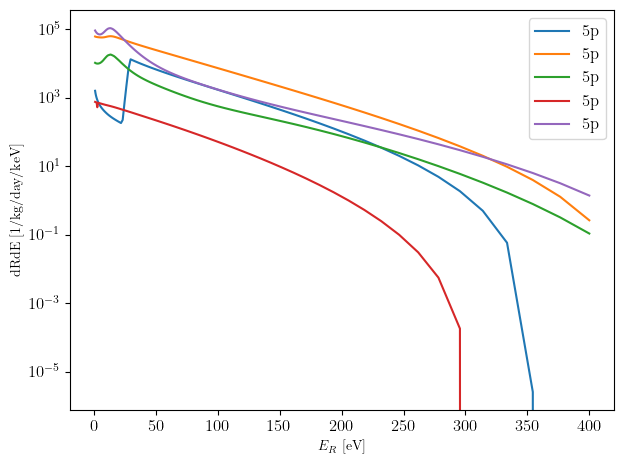

In [18]:
import matplotlib.pyplot as plt
import numericalunits as nu
for shell in dmrates.form_factor.keys:
    if shell in skip_keys[material]:
        continue
    plt.plot(erec,drs[shell].cpu().numpy(),label=f"{test_shell}")

plt.yscale('log')
plt.xlabel('$E_R$ [eV]')
plt.legend()
plt.ylabel("dRdE [1/kg/day/keV]")
plt.show()
plt.close()


In [28]:
import time
start = time.time()
nes = [1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16]
rates_new_allsum = dmrates.calculate_nobleGas_rates(test_mX,halo_model,FDMn,nes,isoangle=None,halo_id_params=None,useVerne=False,calcErrors=None,debug=False,returnShells=False)

rates_new_all,shells = dmrates.calculate_nobleGas_rates(test_mX,halo_model,FDMn,nes,isoangle=None,halo_id_params=None,useVerne=False,calcErrors=None,debug=False,returnShells=True)
end = time.time()
print(f"took {end-start}s")
shells

took 0.07606768608093262s


['Summed', '4p', '4d', '5s', '4s', '5p']

In [22]:
# import time
# start = time.time()
# for isoangle in range(36):
#     dmrates.setup_halo_data(test_mX,FDMn,'modulated',isoangle=35,useVerne=True)
#     drs = dmrates.noble_dRdE(test_mX,FDMn,'modulated',halo_id_params=None,debug=False,unitize=True)

#     rates_new_allsum = dmrates.calculate_nobleGas_rates(test_mX,halo_model,FDMn,nes,isoangle=isoangle,halo_id_params=None,useVerne=True,calcErrors=None,debug=False,returnShells=False)
# end = time.time()
# print(f"took {end-start}s")

<>:4: SyntaxWarning: invalid escape sequence '\c'
<>:4: SyntaxWarning: invalid escape sequence '\s'
<>:4: SyntaxWarning: invalid escape sequence '\c'
<>:4: SyntaxWarning: invalid escape sequence '\s'
C:\Users\Ansh\AppData\Local\Temp\ipykernel_34168\4003701623.py:4: SyntaxWarning: invalid escape sequence '\c'
  title = f"$m_\chi$ = {test_mX} MeV/c$^2$, $\sigma_e =$ {test_cs} cm$^2$, FDM = {fdm_str}"
C:\Users\Ansh\AppData\Local\Temp\ipykernel_34168\4003701623.py:4: SyntaxWarning: invalid escape sequence '\s'
  title = f"$m_\chi$ = {test_mX} MeV/c$^2$, $\sigma_e =$ {test_cs} cm$^2$, FDM = {fdm_str}"


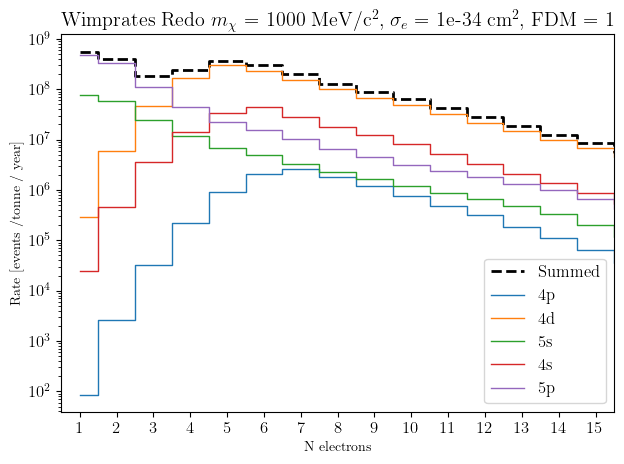

In [29]:
fdm_dict = {0: '1',
            2: '$1/q^2$'}
fdm_str = fdm_dict[FDMn]
title = f"$m_\chi$ = {test_mX} MeV/c$^2$, $\sigma_e =$ {test_cs} cm$^2$, FDM = {fdm_str}" 


plt.title('Wimprates Redo ' + title)# + (' -- SWAP 4s<->4p' if True else ''))


for i,key in enumerate(shells):
        ls = '--' if i == 0 else None
        c = 'k' if i ==0 else None
        lw = 2 if i == 0 else 1
        r = rates_new_all[0][:,i] * nu.tonne * nu.year
        r = r.cpu()
        nes = nes
        plt.plot(nes,r,drawstyle='steps-mid',label=key,ls=ls,c=c,lw=lw)
plt.xticks(np.arange(1, 16))
plt.xlim(0.5, 15.5)
plt.xlabel("N electrons")
plt.legend()
plt.yscale('log')
plt.ylabel(f"Rate [events /tonne / year]")

plt.show()
plt.close()

In [2]:
import DMeRates
import DMeRates.DMeRate as DMeRate
dmrates = DMeRate.DMeRate('Si',QEDark=False)
import numpy as np
dm_masses = np.geomspace(0.5,10,20)
for FDMn in [0,2]:
    dmrates.generate_dat(dm_masses,[1],FDMn,'shm',DoScreen=True,write=True,tag="1e")

CUDA/MPS GPU not found, performing calculations on cpu (if you are doing this on apple silicon you can change your device to mps if you'd like)
Using form factor calculated from file: /Users/ansh/Local/SENSEI/DarkMatterRates/DMeRates/../QCDark/results/Si_final.hdf5


/Users/ansh/Local/SENSEI/DarkMatterRates/DMeRates/DMeRate.py:1011: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


  0%|          | 0/20 [00:00<?, ?it/s]

/Users/ansh/.pyenv/versions/3.12.2/lib/python3.12/site-packages/torch/__init__.py:1236: UserWarning: torch.set_default_tensor_type() is deprecated as of PyTorch 2.1, please use torch.set_default_dtype() and torch.set_default_device() as alternatives. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/tensor/python_tensor.cpp:436.)
  _C._set_default_tensor_type(t)
/Users/ansh/.pyenv/versions/3.12.2/lib/python3.12/site-packages/torchquad/integration/simpson.py:76: UserWarning: N per dimension cannot be even due to necessary subdivisions. N per dim will now be changed to the next lower integer, i.e. 1250 -> 1249.
  warnings.warn(
/Users/ansh/.pyenv/versions/3.12.2/lib/python3.12/site-packages/torch/functional.py:539: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/TensorShape.cpp:3638.)
  return _VF.meshgrid(tensors, *

  0%|          | 0/20 [00:00<?, ?it/s]